## PARAMETER ESTIMATION NOTEBOOK

In [1]:
# =========================================================================================================================== Import
import time
import os
import shutil

%matplotlib ipympl
from matplotlib import pyplot as plt
from scipy.linalg import solve_continuous_lyapunov, block_diag

import rosbag2_py
from rclpy.serialization import serialize_message, deserialize_message
from sensor_msgs.msg import JointState
import casadi

import numpy as np
from tqdm import tqdm

import pandas as pd

from scipy.signal import butter, filtfilt, savgol_filter

import sys
build_path = "./ahand_finger_generatedFiles_py/build"
if os.path.exists(build_path):
    sys.path.append(os.path.abspath(build_path))
else:
    print(f"Warning: path '{build_path}' does not exist.")

from thunder_ahand_finger_py import thunder_ahand_finger

MESH_DIR = './description/urdf/meshes/'
URDF_PATH = './description/urdf/allegro_hand_description_right_B.urdf'
XML_PATH = './description/urdf/allegro_hand_description_right_B.xml'
BAG_PATH = '/home/leo/Desktop/allegro_hand_ros2_ws/workdir/allegro_hand_test_traject_bag'
NEW_BAG_PATH = '/home/leo/Desktop/allegro_hand_ros2_ws/workdir/allegro_hand_torque_filtered_bag'
JOINT_NAMES = ['joint_4_0', 'joint_5_0', 'joint_6_0', 'joint_7_0']
SAVE_FILENAME = '/home/leo/Desktop/ahand_dynamic_friction.txt'

MASSES_URDF = [0.0176, 0.086, 0.0367, 0.0057] # [Kg]
INERTIAS_URDF = [[1.32064e-05, 1.22498e-05, 2.64678e-06],
                 [5.66968e-05, 4.87935e-05, 1.75097e-05],
                 [1.45504e-05, 1.30076e-05, 3.70193e-06],
                 [5.27679e-06, 4.04675e-06, 2.638e-06]] # [Kg m^2]

np.random.seed(41)


/home/leo/.local/lib/python3.10/site-packages/matplotlib/projections/__init__.py:63: UserWarning: Unable to import Axes3D. This may be due to multiple versions of Matplotlib being installed (e.g. as a system package and as a pip package). As a result, the 3D projection is not available.
  warnings.warn("Unable to import Axes3D. This may be due to multiple versions of "
/usr/lib/python3/dist-packages/scipy/__init__.py:146: UserWarning: A NumPy version >=1.17.3 and <1.25.0 is required for this version of SciPy (detected version 1.26.4
  warnings.warn(f"A NumPy version >={np_minversion} and <{np_maxversion}"


In [2]:
# =========================================================================================================================== Define Function
# Bag Read/Write
def read_bag(file_path, topic_name = '/allegroHand_0/joint_states', store=False, path_out=None):
    first = True
    # Open the bag reader
    reader = rosbag2_py.SequentialReader()

    # set options and open the bag
    storage_options = rosbag2_py.StorageOptions(uri=file_path)
    converter_options = rosbag2_py.ConverterOptions('', '')
    reader.open(storage_options, converter_options)

    dataset = []
    header = []
    # scroll the bag
    while reader.has_next():
        (topic, data, t) = reader.read_next()
        if topic == topic_name:
        #if topic == '/allegroHand_0/torque_cmd':
            msg = deserialize_message(data, JointState)
            joint_names = msg.name

            # select specific joints
            indices = [joint_names.index(name) for name in JOINT_NAMES if name in joint_names]
            selected_joint_names = [joint_names[i] for i in indices]
            if first:
                joint_names = msg.name
                # get header
                pos_header    = [f"pos_{name}" for name in selected_joint_names]
                effort_header = [f"eff_{name}" for name in selected_joint_names]
                vel_header    = [f"vel_{name}" for name in selected_joint_names]
                #acc_header    = [f"acc_{name}" for name in selected_joint_names]
                #header = ['t'] + pos_header + vel_header + acc_header + effort_header
                header = ['t'] + pos_header + effort_header + vel_header
                first = False
            elif joint_names != msg.name:
                raise ValueError("Joint names do not match")

            # Store data
            selected_positions = [msg.position[i] for i in indices]
            selected_velocities = [msg.velocity[i] for i in indices]
            selected_effort = [msg.effort[i] for i in indices]
            row = [t/1e9] + selected_positions + selected_effort + selected_velocities
            dataset.append(row)

    # store in dataframe
    df = pd.DataFrame(dataset, columns=header)
    if store:
        df.to_csv(file_path, index=False)

    return df
def write_filtered_bag(file_path, t_log, q_log, tau_log, joint_names_filtered):
    if os.path.exists(file_path):
        print(f"Overwriting existing bag: {file_path}")
        shutil.rmtree(file_path)
    all_joint_names = [f'joint_{i}_0' for i in range(15)]
    # Create writer
    writer = rosbag2_py.SequentialWriter()
    storage_options = rosbag2_py.StorageOptions(uri=file_path, storage_id='sqlite3')
    converter_options = rosbag2_py.ConverterOptions('', '')
    writer.open(storage_options, converter_options)

    # Create topic metadata
    topic_name = '/allegroHand_0/torque_cmd'
    topic_type = 'sensor_msgs/msg/JointState'
    writer.create_topic(rosbag2_py.TopicMetadata(name=topic_name,
                                                 type=topic_type,
                                                 serialization_format='cdr'))

    # Map filtered indices to full joint list
    idx_map = [all_joint_names.index(j) if j in all_joint_names else None for j in joint_names_filtered]

    # Write data
    for i in range(len(t_log)):
        msg = JointState()
        msg.header.stamp.sec = int(t_log[i])
        msg.header.stamp.nanosec = int((t_log[i] - int(t_log[i])) * 1e9)
        msg.name = all_joint_names
        # Initialize all zeros
        q_full = np.zeros(15)
        tau_full = np.zeros(15)
        # Fill available joints
        for j, idx in enumerate(idx_map):
            if idx is not None:
                q_full[idx] = q_log[i, j]
                tau_full[idx] = tau_log[i, j]

        msg.position = q_full.tolist()
        msg.effort = tau_full.tolist()
        writer.write(topic_name, serialize_message(msg), int(t_log[i]*1e9))

    print(f"Filtered bag written to {file_path} with all joints 0-14")


# Matrix Eigenvalues
def powerm(v, A, niter): #POWER ITERATION METHOD
    for i in range(niter):
        v = A @ v
        v = v/casadi.norm_2(v)
    l = v.T@A@v
    return v, l
def def_powerm(a, niter=None): #DEFLATION VERSION OF PIM FOR 3X3 MATRIX ---> CALCULATE ALL EIGENVALUES FROM GREATER TO SMALLER
    #AND THEIR EIGENVECTORS
    v0 = casadi.DM([1,1,1])

    if niter is None:
        niter = 40

    v1,l1 = powerm(v0, a, niter)

    v0 = casadi.DM([0,1,1])
    a2 = a - l1*(v1 @ v1.T)
    v2, l2 = powerm(v0, a2, niter)

    v0 = casadi.DM([0,0,1])
    a3 = a2 - l2 * (v2 @ v2.T)
    v3, l3 = powerm(v0, a3, niter)


    D = casadi.vertcat(l1,l2,l3)
    V = casadi.horzcat(v1,v2,v3)
    return V, D

# Skew-symmetric matrix
def skew(v):
    return np.array([[0, -v[2], v[1]],
                     [v[2], 0, -v[0]],
                     [-v[1], v[0], 0]])

# Dynamic Parameters Store/Load
def save_dynamics(filename, hat_Pi, num_joints):
    par_per_link = int(hat_Pi.shape[0]/num_joints)

    masses = [(hat_Pi[i*par_per_link]).item() for i in range(num_joints)]

    CoMs_x = [(hat_Pi[i*par_per_link+1]/masses[i]).item() for i in range(num_joints)]        #pi = m*cx
    CoMs_y = [(hat_Pi[i*par_per_link+2]/masses[i]).item() for i in range(num_joints)]
    CoMs_z = [(hat_Pi[i*par_per_link+3]/masses[i]).item() for i in range(num_joints)]

    Is_xx = [(hat_Pi[i*par_per_link+4] - (masses[i]*CoMs_y[i]**2 - masses[i]*CoMs_z[i]**2)).item()      for i in range(num_joints)]
    Is_xy = [(hat_Pi[i*par_per_link+5] - (masses[i]*CoMs_x[i]*CoMs_y[i])).item()                        for i in range(num_joints)]
    Is_xz = [(hat_Pi[i*par_per_link+5] - (masses[i]*CoMs_x[i]*CoMs_z[i])).item()                        for i in range(num_joints)]
    Is_yy = [(hat_Pi[i*par_per_link+7] - (masses[i]*CoMs_x[i]**2 - masses[i]*CoMs_z[i]**2)).item()   for i in range(num_joints)]
    Is_yz = [(hat_Pi[i*par_per_link+8] - (masses[i]*CoMs_y[i]*CoMs_z[i])).item()   for i in range(num_joints)]
    Is_zz = [(hat_Pi[i*par_per_link+9] - (masses[i]*CoMs_x[i]**2 - masses[i]*CoMs_y[i]**2)).item()   for i in range(num_joints)]
    if par_per_link>10:
        Ds = [(hat_Pi[i*par_per_link+10]).item()        for i in range(n)]
        Fs = [(hat_Pi[i*par_per_link+11]).item()        for i in range(n)]

    with open(filename, 'w') as f:
        f.write("=== Dynamic parameters ======\n")
        f.write(f"PI size: {hat_Pi.shape}\n")
        for i in range(num_joints):
            f.write(f"\tlink {i+1}:\n")
            f.write(f"\t\tinertial:\n")
            f.write(f"\t\t\tsymb: [1,1,1,1,1,1,1,1,1,1]\n")
            f.write(f"\t\t\tmass: {masses[i]}\n")
            f.write(f"\t\t\tCoM_x: {CoMs_x[i]}\n")
            f.write(f"\t\t\tCoM_y: {CoMs_y[i]}\n")
            f.write(f"\t\t\tCoM_z: {CoMs_z[i]}\n")
            f.write(f"\t\t\tIxx: {Is_xx[i]}\n")
            f.write(f"\t\t\tIxy: {Is_xy[i]}\n")
            f.write(f"\t\t\tIxz: {Is_xz[i]}\n")
            f.write(f"\t\t\tIyy: {Is_yy[i]}\n")
            f.write(f"\t\t\tIyz: {Is_yz[i]}\n")
            f.write(f"\t\t\tIzz: {Is_zz[i]}\n")
            if par_per_link>10:
                f.write(f"\t\tfriction:\n")
                f.write(f"\t\t\tsymb: [1,1]\n")
                f.write(f"\t\t\tDl: [{Ds[i]},{Fs[i]}]\n")
        f.write("=============================\n")
def load_dynamics(filename, num_joints): # filename -> (hat_Pi, dict)
    dynamics = {}
    hat_Pi = np.zeros(12*num_joints)
    with open(filename, 'r') as f:
        lines = f.readlines()

    for line in lines:
        line = line.strip()
        if line.startswith('mass:'):
            dynamics.setdefault('mass', []).append(float(line.split(':')[1]))
        elif line.startswith('CoM_x:'):
            dynamics.setdefault('CoM_x', []).append(float(line.split(':')[1]))
        elif line.startswith('CoM_y:'):
            dynamics.setdefault('CoM_y', []).append(float(line.split(':')[1]))
        elif line.startswith('CoM_z:'):
            dynamics.setdefault('CoM_z', []).append(float(line.split(':')[1]))
        elif line.startswith('Ixx:'):
            dynamics.setdefault('Ixx', []).append(float(line.split(':')[1]))
        elif line.startswith('Ixy:'):
            dynamics.setdefault('Ixy', []).append(float(line.split(':')[1]))
        elif line.startswith('Ixz:'):
            dynamics.setdefault('Ixz', []).append(float(line.split(':')[1]))
        elif line.startswith('Iyy:'):
            dynamics.setdefault('Iyy', []).append(float(line.split(':')[1]))
        elif line.startswith('Iyz:'):
            dynamics.setdefault('Iyz', []).append(float(line.split(':')[1]))
        elif line.startswith('Izz:'):
            dynamics.setdefault('Izz', []).append(float(line.split(':')[1]))

    # reconstruct hat_Pi
    hat_Pi[0::12] = dynamics['mass']
    hat_Pi[1::12] = dynamics['CoM_x'] * dynamics['mass']
    hat_Pi[2::12] = dynamics['CoM_y'] * dynamics['mass']
    hat_Pi[3::12] = dynamics['CoM_z'] * dynamics['mass']
    hat_Pi[4::12] = dynamics['Ixx'] + dynamics['mass'] * (dynamics['CoM_y']**2 + dynamics['CoM_z']**2)
    hat_Pi[5::12] = dynamics['Ixy'] + dynamics['mass'] * (dynamics['CoM_x'] * dynamics['CoM_y'])
    hat_Pi[6::12] = dynamics['Ixz'] + dynamics['mass'] * (dynamics['CoM_x'] * dynamics['CoM_z'])
    hat_Pi[7::12] = dynamics['Iyy'] + dynamics['mass'] * (dynamics['CoM_x']**2 + dynamics['CoM_z']**2)
    hat_Pi[8::12] = dynamics['Iyz'] + dynamics['mass'] * (dynamics['CoM_y'] * dynamics['CoM_z'])
    hat_Pi[9::12] = dynamics['Izz'] + dynamics['mass'] * (dynamics['CoM_x']**2 + dynamics['CoM_y']**2)


    return hat_Pi, dynamics

def print_result(hat_Pi, par_per_link):
    masses = [(hat_Pi[i*par_per_link]).item() for i in range(n)]

    CoMs_x = [(hat_Pi[i*par_per_link+1]/masses[i]).item() for i in range(n)]        #pi = m*cx
    CoMs_y = [(hat_Pi[i*par_per_link+2]/masses[i]).item() for i in range(n)]
    CoMs_z = [(hat_Pi[i*par_per_link+3]/masses[i]).item() for i in range(n)]

    Is_xx = [(hat_Pi[i*par_per_link+4] - (masses[i]*CoMs_y[i]**2 - masses[i]*CoMs_z[i]**2)).item()        for i in range(n)]
    Is_xy = [(hat_Pi[i*par_per_link+5] - (masses[i]*CoMs_x[i]*CoMs_y[i])).item()                          for i in range(n)]
    Is_xz = [(hat_Pi[i*par_per_link+5] - (masses[i]*CoMs_x[i]*CoMs_z[i])).item()                          for i in range(n)]
    Is_yy = [(hat_Pi[i*par_per_link+7] - (masses[i]*CoMs_x[i]**2 - masses[i]*CoMs_z[i]**2)).item()        for i in range(n)]
    Is_yz = [(hat_Pi[i*par_per_link+8] - (masses[i]*CoMs_y[i]*CoMs_z[i])).item()                          for i in range(n)]
    Is_zz = [(hat_Pi[i*par_per_link+9] - (masses[i]*CoMs_x[i]**2 - masses[i]*CoMs_y[i]**2)).item()        for i in range(n)]

    if par_per_link>10:
        Ds = [(hat_Pi[i*par_per_link+10]).item()        for i in range(n)]
        Fs = [(hat_Pi[i*par_per_link+11]).item()        for i in range(n)]
    print("=== Dynamic parameters ======")
    print("PI size:", hat_Pi.shape)
    for i in range(thunder_ahand.get_numJoints()):
        print(f"\tlink {i+1}:")
        print(f"\t\tinertial:")
        print(f"\t\t\tsymb: [1,1,1,1,1,1,1,1,1,1]")
        print(f"\t\t\tmass: {masses[i]}")
        print(f"\t\t\tCoM_x: {CoMs_x[i]}")
        print(f"\t\t\tCoM_y: {CoMs_y[i]}")
        print(f"\t\t\tCoM_z: {CoMs_z[i]}")
        print(f"\t\t\tIxx: {Is_xx[i]}")
        print(f"\t\t\tIxy: {Is_xy[i]}")
        print(f"\t\t\tIxz: {Is_xz[i]}")
        print(f"\t\t\tIyy: {Is_yy[i]}")
        print(f"\t\t\tIyz: {Is_yz[i]}")
        print(f"\t\t\tIzz: {Is_zz[i]}")
        if par_per_link>10:
            print(f"\t\tfriction: ")
            print(f"\t\t\tsymb: [1,1]")
            print(f"\t\t\tDl: [{Ds[i]},{Fs[i]}]")
    print("=============================")

Extract Data

In [3]:
# =========================================================================================================================== Start
df = read_bag(BAG_PATH, topic_name='/allegroHand_0/joint_states', store=False)
#df2 = read_bag(BAG_PATH, topic_name='/allegroHand_0/torque_cmd',store=False)

[INFO] [1762097386.067631778] [rosbag2_storage]: Opened database '/home/leo/Desktop/allegro_hand_ros2_ws/workdir/allegro_hand_test_traject_bag/allegro_hand_test_traject_bag_0.db3' for READ_ONLY.


In [24]:
# =========================================================================================================================== Process data
INTERVAL = [20, 60]
t0 = df['t'].to_numpy()[0]


df = df[(df['t'] - t0 >= INTERVAL[0]) & (df['t'] - t0 <= INTERVAL[1])]
t_log = df['t'].to_numpy() - t0
q_log = df[[col for col in df.columns if col.startswith('pos_')]].to_numpy()
qd_log = df[[col for col in df.columns if col.startswith('vel_')]].to_numpy()
tau_log = df[[col for col in df.columns if col.startswith('eff_')]].to_numpy()

Dt = np.mean(np.diff(t_log))    # sampling period
F_s = 1.0 / Dt                  # sampling frequency
t_ori = t_log.copy()            # store original data
q_ori = q_log.copy()
qd_ori = qd_log.copy()
tau_ori = tau_log.copy()


"""
df2 = df2[(df2['t'] - t0 >= INTERVAL[0]) & (df2['t'] - t0 <= INTERVAL[1])]
t_log2 = df2['t'].to_numpy() - t0
q_log2 = df2[[col for col in df2.columns if col.startswith('pos_')]].to_numpy()
qd_log2 = df2[[col for col in df2.columns if col.startswith('vel_')]].to_numpy()
tau_log2 = df2[[col for col in df2.columns if col.startswith('eff_')]].to_numpy()
t_ori2 = t_log2.copy()            # store original data
q_ori2 = q_log2.copy()
qd_ori2 = qd_log2.copy()
tau_ori2 = tau_log2.copy()
"""
# 1. Filtering position
""" Savitzy-golay
# Parameters
window_length = 41   # must be odd, ~ window of ~50 ms if fs=1000Hz
polyorder = 3        # polynomial order (2–4 typical)
# Filter position
q_filt = savgol_filter(q_log, window_length=window_length, polyorder=polyorder, axis=0)
# First derivative → velocity
qd_log = savgol_filter(q_log, window_length=window_length, polyorder=polyorder, deriv=1, delta=dt, axis=0)
# Second derivative → acceleration
qdd_log = savgol_filter(q_log, window_length=window_length, polyorder=polyorder, deriv=2, delta=dt, axis=0)
# store filtered joint position
q_ori = q_log
q_log = q_filt
"""

""" moving average filter + finite difference
window_size = 50
# 1. filter position
q_filt = np.convolve(q_log[:,0], np.ones(window_size)/window_size, mode='same').reshape(-1,1)
for i in range(1,q_log.shape[1]):
    # filtering each joint separately
    q_filt_i = np.convolve(q_log[:,i], np.ones(window_size)/window_size, mode='same').reshape(-1,1)
    q_filt = np.hstack((q_filt, q_filt_i))

# discard edges
edge = window_size // 2
q_log = q_filt[edge:-edge,:]
t_log = t_log[edge:-edge]

# 2. First derivative → velocity
qd = np.gradient(q_log, dt, axis=0)
t_vel = t_log.copy()
# filter velocity
qd_filt = np.convolve(qd[:,0], np.ones(window_size)/window_size, mode='same').reshape(-1,1)
for i in range(1, qd.shape[1]):
    # filtering each joint separately
    qd_filt_i = np.convolve(qd[:,i], np.ones(window_size)/window_size, mode='same').reshape(-1,1)
    qd_filt =  np.hstack((qd_filt, qd_filt_i))
# discard edges
t_log = t_log[edge:-edge]
q_log = q_log[edge:-edge,:]
qd_log = qd_filt[edge:-edge,:]

# 3. Second derivative → acceleration
qdd = np.gradient(qd_log, dt, axis=0)
t_acc = t_log.copy()
# filter accedeleration
qdd_filt = np.convolve(qdd[:,0], np.ones(window_size)/window_size, mode='same').reshape(-1,1)
for i in range(1,qd.shape[1]):
    # filtering each joint separately
    qdd_filt_i = np.convolve(qdd[:,i], np.ones(window_size)/window_size, mode='same').reshape(-1,1)
    qdd_filt =  np.hstack((qdd_filt, qdd_filt_i))
# discard edges
t_log = t_log[edge:-edge]
q_log = q_log[edge:-edge,:]
qd_log = qd_log[edge:-edge,:]
qdd_log = qdd_filt[edge:-edge,:]"""

""" Kalman Filtering
"""
class KalmanFilter():
    def __init__(self, sigma_u, sigma_r):
        # state
        self.hat_x = np.zeros((3, 1)) # x = {q, dq, ddq} [rad, rad/s, rad/s^2]
        #self.Pk = 1e-7*np.eye(3,3)
        self.Pk = np.array([[7.43901056e-08, 2.43974556e-05, 4.00077293e-03],
                            [2.43974556e-05, 1.59072400e-02, 3.90492122e+00],
                            [4.00077293e-03, 3.90492122e+00, 1.28068298e+03]])
        # dynamics
        self.Ak = np.array([[0, 1, 0],
                            [0, 0, 1],
                            [0, 0, 0]])
        self.A2k = np.array([[0, 0, 1],
                             [0, 0, 0],
                             [0, 0, 0]])
        self.Hk = np.array([[1, 0, 0]])
        # Kalman values
        self.sigma_u = sigma_u # process noise
        self.Rk = sigma_r * np.eye(1)  # measurement noise

    def prediction(self, dt):
        I = np.eye(3)
        Fd = I + dt*self.Ak + dt*dt/2*self.A2k # discrete transiction
        self.hat_x = Fd @ self.hat_x

        G = np.array([[1/2*dt*dt],
                      [dt],
                      [1]])

        Qk = (self.sigma_u*self.sigma_u)*(G @ G.T)

        self.Pk = Fd @ self.Pk @ Fd.T + Qk

    def update(self, z):
        I = np.eye(3)
        yk = z - self.Hk @ self.hat_x
        Sk = self.Hk @ self.Pk @ self.Hk.T + self.Rk
        Kk = self.Pk @ self.Hk.T @ np.linalg.inv(Sk)
        self.hat_x = self.hat_x + Kk @ yk

        self.Pk = (I - Kk @ self.Hk) @ self.Pk @ (I - Kk @ self.Hk).T + Kk @ self.Rk @ Kk.T

    def get_q(self):
        return self.hat_x[0]
    def get_qd(self):
        return self.hat_x[1]
    def get_qdd(self):
        return self.hat_x[2]

KFs = []
for i in range(4):
    KFs.append(KalmanFilter(25, 1e-7))

q_kf_filt = []
qd_kf_filt = []
qdd_kf_filt = []
q_tmp = []
qd_tmp = []
qdd_tmp = []

for i in range(len(t_log)):
#for i in range(5):
    for j in range(4):
        try:
            dt = t_log[i+1] - t_log[i]
        except:
            ft = t_log[i] - t_log[i-1]
        if i == 0:
            KFs[j].hat_x[0] = q_log[i][j]
        KFs[j].prediction(0.002)
        KFs[j].update(q_log[i][j])

        q_tmp.append(KFs[j].get_q())
        qd_tmp.append(KFs[j].get_qd())
        qdd_tmp.append(KFs[j].get_qdd())

    q_kf_filt.append(np.array(q_tmp))
    qd_kf_filt.append(np.array(qd_tmp))
    qdd_kf_filt.append(np.array(qdd_tmp))
    q_tmp = []
    qd_tmp = []
    qdd_tmp = []


q_kf_filt = np.array(q_kf_filt)
qd_kf_filt = np.array(qd_kf_filt)
qdd_kf_filt = np.array(qdd_kf_filt)

## Butterworth filter + finite difference
## Design Butterworth filter
#order = 4
#cutoff_freq = 1.0  # Hz
#b, a = butter(order, cutoff_freq / (0.5 * f_s), btype='low')
## 1. Filter position
#q_filt = filtfilt(b, a, q_log, axis=0)
#q_log = q_filt
## 2. First derivative → velocity
#qd = np.gradient(q_log, dt, axis=0)
#qd_filt = filtfilt(b, a, qd, axis=0)
#qd_log = qd_filt
#t_vel = t_log.copy()
## 3. Second derivative → acceleration
#qdd = np.gradient(qd_log, dt, axis=0)
#qdd_filt = filtfilt(b, a, qdd, axis=0)
#qdd_log = qdd_filt
#t_acc = t_log.copy()
## 4. commanded torque
#tau_filt = filtfilt(b, a, tau_log, axis=0)
#tau_log = tau_filt

#write_filtered_bag(NEW_BAG_PATH, t_log, q_log, tau_log, JOINT_NAMES)

/home/leo/.local/lib/python3.10/site-packages/numpy/core/fromnumeric.py:3504: RuntimeWarning: Mean of empty slice.
  return _methods._mean(a, axis=axis, dtype=dtype,
/home/leo/.local/lib/python3.10/site-packages/numpy/core/_methods.py:129: RuntimeWarning: invalid value encountered in scalar divide
  ret = ret.dtype.type(ret / rcount)


In [5]:
# =========================================================================================================================== Compute regressor
thunder_ahand = thunder_ahand_finger()
thunder_ahand.load_conf("/home/leo/thunder_dynamics/ahand_finger_generatedFiles/ahand_finger_conf.yaml")

Y_log = []
for i in range(t_log.shape[0]):
    #q =q_log[i,:]
    #dq = qd_log[i,:]
    #ddq = qdd_log[i,:]
    q =q_kf_filt[i,:]
    dq = qd_kf_filt[i,:]
    ddq = qdd_kf_filt[i,:]

    thunder_ahand.set_q(q)
    thunder_ahand.set_dq(dq)
    thunder_ahand.set_dqr(dq)
    thunder_ahand.set_ddqr(ddq)
    Y = thunder_ahand.get_reg_M() + thunder_ahand.get_reg_C() + thunder_ahand.get_reg_G()
    #Y_log.append(Y)
    # friction damping and static
    Y_d = np.diag(qd_log[i])
    Y_s = np.diag(2/(1+np.exp(-20*qd_log[i])) - 1)

    # Convert Unit Measures
    Y[:,0:40:10] = Y[:,0:40:10]/1e3                   # [Kg] -> [g]
    Y[:,1:40:10] = Y[:,1:40:10]/(1e6)                 # [Kg*m] -> [g*mm]
    Y[:,2:40:10] = Y[:,2:40:10]/(1e6)                 # [Kg*m] -> [g*mm]
    Y[:,3:40:10] = Y[:,3:40:10]/(1e6)                 # [Kg*m] -> [g*mm]
    Y[:,4:40:10] = Y[:,4:40:10]/(1e9)                 # [Kg*m^2] -> [g*mm^2]
    Y[:,5:40:10] = Y[:,5:40:10]/(1e9)                 # [Kg*m^2] -> [g*mm^2]
    Y[:,6:40:10] = Y[:,6:40:10]/(1e9)                 # [Kg*m^2] -> [g*mm^2]
    Y[:,7:40:10] = Y[:,7:40:10]/(1e9)                 # [Kg*m^2] -> [g*mm^2]
    Y[:,8:40:10] = Y[:,8:40:10]/(1e9)                 # [Kg*m^2] -> [g*mm^2]
    Y[:,9:40:10] = Y[:,9:40:10]/(1e9)                 # [Kg*m^2] -> [g*mm^2]
    Y_log.append(np.hstack([Y, Y_d, Y_s]))


print("> Computing Dynamics param")
M = len(t_log)
n = thunder_ahand.get_numJoints()
print("Number of samples (M): ", M)
YY = np.concatenate([np.asarray(Y) for Y in Y_log], axis=0)
TTau = np.concatenate([np.asarray(t).reshape(n, 1) for t in tau_log], axis=0)

p = Y_log[0].shape[1]
par_per_link = int(p/n)
print("Shape YY (Mnxp): ", YY.shape)
print("Shape TTau (Mnx1): ", TTau.shape)


# Method 1 - Pinv
print("Computing initial guess by pseudoinverse")
print("\t Reducing YY to minimal rank")
print("\t Computing initial guess by pseudoinverse")
hat_Pi = np.linalg.pinv(YY)@TTau
print_result(hat_Pi, par_per_link)


> Computing Dynamics param
Number of samples (M):  19764
Shape YY (Mnxp):  (79056, 48)
Shape TTau (Mnx1):  (79056, 1)
Computing initial guess by pseudoinverse
	 Reducing YY to minimal rank
	 Computing initial guess by pseudoinverse
=== Dynamic parameters ======
PI size: (48, 1)
	link 1:
		inertial:
			symb: [1,1,1,1,1,1,1,1,1,1]
			mass: 0.0
			CoM_x: -inf
			CoM_y: -inf
			CoM_z: -inf
			Ixx: nan
			Ixy: nan
			Ixz: nan
			Iyy: nan
			Iyz: nan
			Izz: nan
		friction: 
			symb: [1,1]
			Dl: [-1.8509818069775433e-05,7498.516816376837]
	link 2:
		inertial:
			symb: [1,1,1,1,1,1,1,1,1,1]
			mass: -3243.4794389513427
			CoM_x: 5.946779942989448e-11
			CoM_y: -108.15203289687074
			CoM_z: -85.80209899176126
			Ixx: 14060036.15490952
			Ixy: -89943.715539358
			Ixz: -89943.71553504709
			Iyy: -23788569.93277458
			Iyz: 30098422.297780123
			Izz: -37938461.06202682
		friction: 
			symb: [1,1]
			Dl: [1042.6264801293728,-127.28198383760704]
	link 3:
		inertial:
			symb: [1,1,1,1,1,1,1,1,1,1]
	

/tmp/ipykernel_3756/2576789651.py:219: RuntimeWarning: divide by zero encountered in divide
  CoMs_x = [(hat_Pi[i*par_per_link+1]/masses[i]).item() for i in range(n)]        #pi = m*cx
/tmp/ipykernel_3756/2576789651.py:220: RuntimeWarning: divide by zero encountered in divide
  CoMs_y = [(hat_Pi[i*par_per_link+2]/masses[i]).item() for i in range(n)]
/tmp/ipykernel_3756/2576789651.py:221: RuntimeWarning: divide by zero encountered in divide
  CoMs_z = [(hat_Pi[i*par_per_link+3]/masses[i]).item() for i in range(n)]


Define standard problem

In [6]:
# =========================================================================================================================== Define optim problem
# Method 2 - Least Squares
positive_th = 0.001
hat_Pi_sym = casadi.SX.sym('Pi', p, 1)    # Parameters to estimate
g = []          # Constraints
ub = []         # Upper bound
lb = []         # Lower bound


for i in range(n):
    # Mass must be positive
    g.append(hat_Pi_sym[i*10])
    lb.append(MASSES_URDF[i]*990)          # [g]
    ub.append(MASSES_URDF[i]*1010)

    # CoM inside a spere of radius r
    cx = hat_Pi_sym[i*10 + 1]/hat_Pi_sym[i*10]
    cy = hat_Pi_sym[i*10 + 2]/hat_Pi_sym[i*10]
    cz = hat_Pi_sym[i*10 + 3]/hat_Pi_sym[i*10]
    c = np.array([cx,cy,cz])

    g.append(np.sqrt(c@c.T))
    lb.append(0)                    # [mm]
    ub.append(100)

    # Semi-definite inertia matrix
    Jxx = hat_Pi_sym[i*10 + 4]
    Jxy = hat_Pi_sym[i*10 + 5]
    Jxz = hat_Pi_sym[i*10 + 6]
    Jyy = hat_Pi_sym[i*10 + 7]
    Jyz = hat_Pi_sym[i*10 + 8]
    Jzz = hat_Pi_sym[i*10 + 9]
    J = np.array([[Jxx, Jxy, Jxz],
                   [Jxy, Jyy, Jyz],
                   [Jxz, Jyz, Jzz]])
    Ib = J - hat_Pi_sym[i*10] * skew(c)@skew(c).T

    _,l = def_powerm(Ib, niter=40)
    g.append((Ib[0,0]+Ib[1,1]+Ib[2,2])/2 - l[0])

    lb.append(positive_th)
    ub.append(np.inf)

    if par_per_link>10:
        # Friction
        # Damping
        g.append(hat_Pi_sym[40 + i])
        lb.append(0)
        ub.append(2)
        # Static
        g.append(hat_Pi_sym[44 + i])
        lb.append(0)
        ub.append(2)

# Problem
prob = {}
prob['x'] = hat_Pi_sym
prob['f'] = (YY@hat_Pi_sym - TTau).T@(YY@hat_Pi_sym - TTau)
prob['g'] = casadi.vertcat(*g)
# Options
opts = {
    "ipopt": {
        "tol": 1e-6,
        "constr_viol_tol": 1e-6,
        "acceptable_tol": 1e-5,
        "dual_inf_tol": 1e-6,
        "compl_inf_tol": 1e-6,
        "max_iter": 3000,
    }
}
# Solver
solver = casadi.nlpsol('sol', 'ipopt', prob, opts)


In [7]:
# =========================================================================================================================== Solve optim problem
#hat_Pi_0 = np.random.rand(p,1)
hat_Pi_0 = 1*np.ones((p,1))
hat_Pi_0[0:40:10] = np.array(MASSES_URDF).reshape(hat_Pi_0[0:40:10].shape)

hat_Pi_0[1:40:10] = 1*np.ones_like(hat_Pi_0[3:40:10])
hat_Pi_0[2:40:10] = 1*np.ones_like(hat_Pi_0[3:40:10])
hat_Pi_0[3:40:10] = 0*np.ones_like(hat_Pi_0[3:40:10])

hat_Pi_0[4:40:10] = np.array([(INERTIAS_URDF[i][0]) for i in range(n)]).reshape(hat_Pi_0[4:40:10].shape)
hat_Pi_0[7:40:10] = np.array([(INERTIAS_URDF[i][1]) for i in range(n)]).reshape(hat_Pi_0[7:40:10].shape)
hat_Pi_0[9:40:10] = np.array([(INERTIAS_URDF[i][2]) for i in range(n)]).reshape(hat_Pi_0[9:40:10].shape)

sol = solver(x0=hat_Pi_0, lbg=lb,ubg=ub)
hat_Pi = sol['x'].full()
#load_dynamics('./res.txt',4)
resid = YY@hat_Pi - TTau
print("Residual norm: ", np.linalg.norm(YY@hat_Pi - TTau))

print("> Extracting dinamic parameters")
print(par_per_link)

# reconvert Unit Measures
hat_Pi[0:40:10] = hat_Pi[0:40:10]/1e3                   # [g] -> [Kg]
hat_Pi[1:40:10] = hat_Pi[1:40:10]/(1e6)                 # [g*mm] -> [Kg*m]
hat_Pi[2:40:10] = hat_Pi[2:40:10]/(1e6)                 # [g*mm] -> [Kg*m]
hat_Pi[3:40:10] = hat_Pi[3:40:10]/(1e6)                 # [g*mm] -> [Kg*m]
hat_Pi[4:40:10] = hat_Pi[4:40:10]/(1e9)                 # [g*mm^2] -> [Kg*m^2]
hat_Pi[5:40:10] = hat_Pi[5:40:10]/(1e9)                 # [g*mm^2] -> [Kg*m^2]
hat_Pi[6:40:10] = hat_Pi[6:40:10]/(1e9)                 # [g*mm^2] -> [Kg*m^2]
hat_Pi[7:40:10] = hat_Pi[7:40:10]/(1e9)                 # [g*mm^2] -> [Kg*m^2]
hat_Pi[8:40:10] = hat_Pi[8:40:10]/(1e9)                 # [g*mm^2] -> [Kg*m^2]
hat_Pi[9:40:10] = hat_Pi[9:40:10]/(1e9)                 # [g*mm^2] -> [Kg*m^2]

masses = [(hat_Pi[i*10]).item() for i in range(n)]

CoMs_x = [(hat_Pi[i*10+1]/masses[i]).item() for i in range(n)]        # pi  = m*CoM
CoMs_y = [(hat_Pi[i*10+2]/masses[i]).item() for i in range(n)]
CoMs_z = [(hat_Pi[i*10+3]/masses[i]).item() for i in range(n)]

Is_xx = [(hat_Pi[i*10+4] - (masses[i]*CoMs_y[i]**2 - masses[i]*CoMs_z[i]**2)).item()        for i in range(n)]  # pi = J
Is_xy = [(hat_Pi[i*10+5] - (masses[i]*CoMs_x[i]*CoMs_y[i])).item()                          for i in range(n)]
Is_xz = [(hat_Pi[i*10+5] - (masses[i]*CoMs_x[i]*CoMs_z[i])).item()                          for i in range(n)]
Is_yy = [(hat_Pi[i*10+7] - (masses[i]*CoMs_x[i]**2 - masses[i]*CoMs_z[i]**2)).item()        for i in range(n)]
Is_yz = [(hat_Pi[i*10+8] - (masses[i]*CoMs_y[i]*CoMs_z[i])).item()                          for i in range(n)]
Is_zz = [(hat_Pi[i*10+9] - (masses[i]*CoMs_x[i]**2 - masses[i]*CoMs_y[i]**2)).item()        for i in range(n)]

if par_per_link>10:
    Ds = [(hat_Pi[40 + i]).item()        for i in range(n)]
    Fs = [(hat_Pi[44 + i]).item()        for i in range(n)]

print("=== Dynamic parameters ======")
print("PI size:", hat_Pi.shape)
print("PI: \n", hat_Pi)
for i in range(thunder_ahand.get_numJoints()):
    print(f"\tlink {i+1}:")
    print(f"\t\tinertial:")
    print(f"\t\t\tsymb: [1,1,1,1,1,1,1,1,1,1]")
    print(f"\t\t\tmass: {masses[i]}")
    print(f"\t\t\tCoM_x: {CoMs_x[i]}")
    print(f"\t\t\tCoM_y: {CoMs_y[i]}")
    print(f"\t\t\tCoM_z: {CoMs_z[i]}")
    print(f"\t\t\tIxx: {Is_xx[i]}")
    print(f"\t\t\tIxy: {Is_xy[i]}")
    print(f"\t\t\tIxz: {Is_xz[i]}")
    print(f"\t\t\tIyy: {Is_yy[i]}")
    print(f"\t\t\tIyz: {Is_yz[i]}")
    print(f"\t\t\tIzz: {Is_zz[i]}")
    if par_per_link>10:
        print(f"\t\tfriction: ")
        print(f"\t\t\tsymb: [1,1]")
        print(f"\t\t\tDl: [{Ds[i]},{Fs[i]}]")
print("=============================")


******************************************************************************
This program contains Ipopt, a library for large-scale nonlinear optimization.
 Ipopt is released as open source code under the Eclipse Public License (EPL).
         For more information visit https://github.com/coin-or/Ipopt
******************************************************************************

This is Ipopt version 3.14.11, running with linear solver MUMPS 5.4.1.

Number of nonzeros in equality constraint Jacobian...:        0
Number of nonzeros in inequality constraint Jacobian.:       68
Number of nonzeros in Lagrangian Hessian.............:      684

Total number of variables............................:       48
                     variables with only lower bounds:        0
                variables with lower and upper bounds:        0
                     variables with only upper bounds:        0
Total number of equality constraints.................:        0
Total number of inequality c

Define iterative problem

In [ ]:
# =========================================================================================================================== Define optim problem
# Method 2 - Least Squares
positive_th = 0.001
hat_Pi_sym = casadi.SX.sym('Pi', p, 1)    # Parameters to estimate
xi_k = casadi.SX.sym('xi_k', 1, 1)    # Parameters to estimate
nhg = []        # No-Hard Constraints
g = []          # Constraints
ub = []         # Upper bound
lb = []         # Lower bound

Mmax = np.sum(MASSES_URDF)*1000+10
Mmin = np.sum(MASSES_URDF)*1000-10
nhg.append(casadi.mmin( 0,
                        Mmax-(hat_Pi_sym[0]+hat_Pi_sym[par_per_link]+hat_Pi_sym[1*par_per_link]+hat_Pi_sym[2*par_per_link]),
                        (hat_Pi_sym[0]+hat_Pi_sym[par_per_link]+hat_Pi_sym[1*par_per_link]+hat_Pi_sym[2*par_per_link])-Mmin))
for i in range(n):
    # Mass must be positive
    g.append(hat_Pi_sym[i*par_per_link])
    lb.append(MASSES_URDF[i]*1000)          # [g]
    ub.append(MASSES_URDF[i]*1000)

    # CoM inside a spere of radius r
    cx = hat_Pi_sym[i*par_per_link + 1]/hat_Pi_sym[i*par_per_link]
    cy = hat_Pi_sym[i*par_per_link + 2]/hat_Pi_sym[i*par_per_link]
    cz = hat_Pi_sym[i*par_per_link + 3]/hat_Pi_sym[i*par_per_link]

    g.append(cx)
    lb.append(-10)                    # [mm]
    ub.append(10)

    g.append(cy)
    lb.append(-10)                    # [mm]
    ub.append(10)

    g.append(cz)
    lb.append(-10)                    # [mm]
    ub.append(10)
    # Semi-definite inertia matrix
    Jxx = hat_Pi_sym[i*par_per_link + 4]
    Jxy = hat_Pi_sym[i*par_per_link + 5]
    Jxz = hat_Pi_sym[i*par_per_link + 6]
    Jyy = hat_Pi_sym[i*par_per_link + 7]
    Jyz = hat_Pi_sym[i*par_per_link + 8]
    Jzz = hat_Pi_sym[i*par_per_link + 9]
    g.append(Jxx)
    lb.append(positive_th)
    ub.append(np.inf)

    g.append(Jxy)
    lb.append(positive_th)
    ub.append(np.inf)

    g.append(Jxz)
    lb.append(positive_th)
    ub.append(np.inf)

    g.append(Jyy)
    lb.append(positive_th)
    ub.append(np.inf)

    g.append(Jyz)
    lb.append(positive_th)
    ub.append(np.inf)

    g.append(Jzz)
    lb.append(positive_th)
    ub.append(np.inf)

    
    J = np.array([[Jxx, Jxy, Jxz],
                   [Jxy, Jyy, Jyz],
                   [Jxz, Jyz, Jzz]])
    Ib = J - hat_Pi_sym[i*par_per_link] * skew(c)@skew(c).T

    _,l = def_powerm(Ib, niter=40)
    nhg.append(casadi.mmin(0,(Ib[0,0]+Ib[1,1]+Ib[2,2])/2 - l[0]))

    if par_per_link>10:
        # Friction
        # Damping
        g.append(hat_Pi_sym[i*par_per_link+10])
        lb.append(0)
        ub.append(0.2)
        # Static
        g.append(hat_Pi_sym[i*par_per_link+11])
        lb.append(0)
        ub.append(0.01)

# Problem
prob = {}
prob['x'] = hat_Pi_sym
prob['f'] = (YY@hat_Pi_sym - TTau).T@(YY@hat_Pi_sym - TTau) + xi_k * np.sum(nhg)
prob['g'] = casadi.vertcat(*g)
# Options
opts = {
    "ipopt": {
        "tol": 1e-6,
        "constr_viol_tol": 1e-6,
        "acceptable_tol": 1e-5,
        "dual_inf_tol": 1e-6,
        "compl_inf_tol": 1e-6,
        "max_iter": 3000,
    }
}
# Solver
solver = casadi.nlpsol('sol', 'ipopt', prob, opts)

In [ ]:
# =========================================================================================================================== Solve optim problem
#hat_Pi_0 = np.random.rand(p,1)
hat_Pi_0 = 1*np.ones((p,1))
hat_Pi_0[0::par_per_link] = np.array(MASSES_URDF).reshape(hat_Pi_0[0::par_per_link].shape)
hat_Pi_0[4::par_per_link] = np.array([(INERTIAS_URDF[i][0]) for i in range(n)]).reshape(hat_Pi_0[4::par_per_link].shape)
hat_Pi_0[7::par_per_link] = np.array([(INERTIAS_URDF[i][1]) for i in range(n)]).reshape(hat_Pi_0[7::par_per_link].shape)
hat_Pi_0[9::par_per_link] = np.array([(INERTIAS_URDF[i][2]) for i in range(n)]).reshape(hat_Pi_0[8::par_per_link].shape)

for k in range(10):
    sol = solver(x0=hat_Pi_0, p=10*k, lbg=lb,ubg=ub)
    hat_Pi0 = sol['x'].full()
    
hat_Pi = sol['x'].full()
#load_dynamics('./res.txt',4)
resid = YY@hat_Pi - TTau
print("Residual norm: ", np.linalg.norm(YY@hat_Pi - TTau))

print("> Extracting dinamic parameters")
print(par_per_link)

# reconvert Unit Measures
hat_Pi[0::12] = hat_Pi[0::12]/1e3                   # [g] -> [Kg]
hat_Pi[1::12] = hat_Pi[1::12]/(1e6)                 # [g*mm] -> [Kg*m]
hat_Pi[2::12] = hat_Pi[2::12]/(1e6)                 # [g*mm] -> [Kg*m]
hat_Pi[3::12] = hat_Pi[3::12]/(1e6)                 # [g*mm] -> [Kg*m]
hat_Pi[4::12] = hat_Pi[4::12]/(1e9)                 # [g*mm^2] -> [Kg*m^2]
hat_Pi[5::12] = hat_Pi[5::12]/(1e9)                 # [g*mm^2] -> [Kg*m^2]
hat_Pi[6::12] = hat_Pi[6::12]/(1e9)                 # [g*mm^2] -> [Kg*m^2]
hat_Pi[7::12] = hat_Pi[7::12]/(1e9)                 # [g*mm^2] -> [Kg*m^2]
hat_Pi[8::12] = hat_Pi[8::12]/(1e9)                 # [g*mm^2] -> [Kg*m^2]
hat_Pi[9::12] = hat_Pi[9::12]/(1e9)                 # [g*mm^2] -> [Kg*m^2]

masses = [(hat_Pi[i*par_per_link]).item() for i in range(n)]

CoMs_x = [(hat_Pi[i*par_per_link+1]/masses[i]).item() for i in range(n)]        # pi  = m*CoM
CoMs_y = [(hat_Pi[i*par_per_link+2]/masses[i]).item() for i in range(n)]
CoMs_z = [(hat_Pi[i*par_per_link+3]/masses[i]).item() for i in range(n)]

Is_xx = [(hat_Pi[i*par_per_link+4] - (masses[i]*CoMs_y[i]**2 - masses[i]*CoMs_z[i]**2)).item()        for i in range(n)]  # pi = J
Is_xy = [(hat_Pi[i*par_per_link+5] - (masses[i]*CoMs_x[i]*CoMs_y[i])).item()                          for i in range(n)]
Is_xz = [(hat_Pi[i*par_per_link+5] - (masses[i]*CoMs_x[i]*CoMs_z[i])).item()                          for i in range(n)]
Is_yy = [(hat_Pi[i*par_per_link+7] - (masses[i]*CoMs_x[i]**2 - masses[i]*CoMs_z[i]**2)).item()        for i in range(n)]
Is_yz = [(hat_Pi[i*par_per_link+8] - (masses[i]*CoMs_y[i]*CoMs_z[i])).item()                          for i in range(n)]
Is_zz = [(hat_Pi[i*par_per_link+9] - (masses[i]*CoMs_x[i]**2 - masses[i]*CoMs_y[i]**2)).item()        for i in range(n)]

if par_per_link>10:
    Ds = [(hat_Pi[i*par_per_link+10]).item()        for i in range(n)]
    Fs = [(hat_Pi[i*par_per_link+11]).item()        for i in range(n)]

print("=== Dynamic parameters ======")
print("PI size:", hat_Pi.shape)
for i in range(thunder_ahand.get_numJoints()):
    print(f"\tlink {i+1}:")
    print(f"\t\tinertial:")
    print(f"\t\t\tsymb: [1,1,1,1,1,1,1,1,1,1]")
    print(f"\t\t\tmass: {masses[i]}")
    print(f"\t\t\tCoM_x: {CoMs_x[i]}")
    print(f"\t\t\tCoM_y: {CoMs_y[i]}")
    print(f"\t\t\tCoM_z: {CoMs_z[i]}")
    print(f"\t\t\tIxx: {Is_xx[i]}")
    print(f"\t\t\tIxy: {Is_xy[i]}")
    print(f"\t\t\tIxz: {Is_xz[i]}")
    print(f"\t\t\tIyy: {Is_yy[i]}")
    print(f"\t\t\tIyz: {Is_yz[i]}")
    print(f"\t\t\tIzz: {Is_zz[i]}")
    if par_per_link>10:
        print(f"\t\tfriction: ")
        print(f"\t\t\tsymb: [1,1]")
        print(f"\t\t\tDl: [{Ds[i]},{Fs[i]}]")
print("=============================")

Verifie the solution

In [20]:
# =========================================================================================================================== Compute tau_hat
thunder_ahand.set_par_DYN(hat_Pi[:40])
delta_tau = []
for i in range(len(t_log)):
    #q =q_log[i,:]
    #dq = qd_log[i,:]
    #ddq = qdd_log[i,:]
    q = q_kf_filt[i,:]
    dq = qd_kf_filt[i,:]
    ddq = qdd_kf_filt[i,:]

    thunder_ahand.set_q(q)
    thunder_ahand.set_dq(dq)
    thunder_ahand.set_dqr(dq)
    thunder_ahand.set_ddqr(ddq)
    Y = thunder_ahand.get_reg_M() + thunder_ahand.get_reg_C() + thunder_ahand.get_reg_G()
    # add friction damping and static
    Y_d = np.diag(dq.flatten())
    Y_s = np.diag((2/(1+np.exp(-20*dq)) - 1).flatten())
    Y = np.hstack([Y, Y_d, Y_s])

    tau_est = np.array(Y @ hat_Pi).flatten()
    delta_tau.append(tau_log[i,:] - tau_est)
delta_tau = np.array(delta_tau)

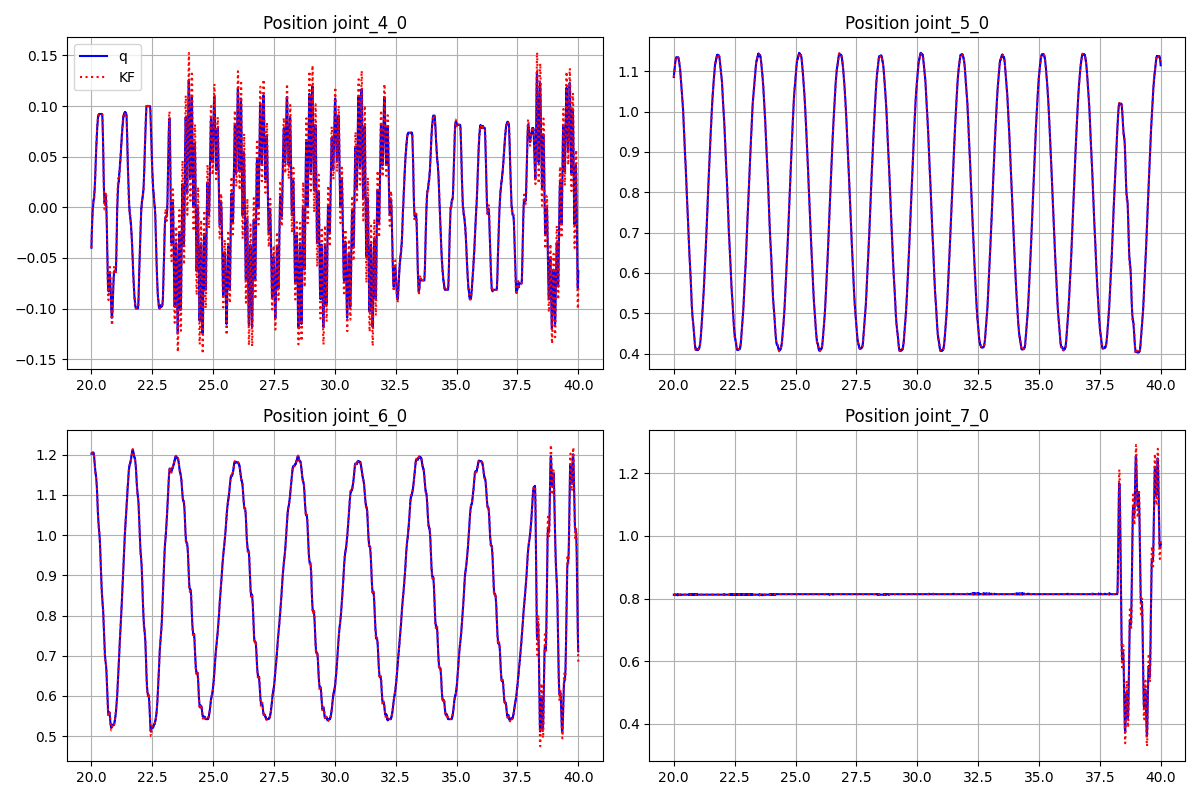

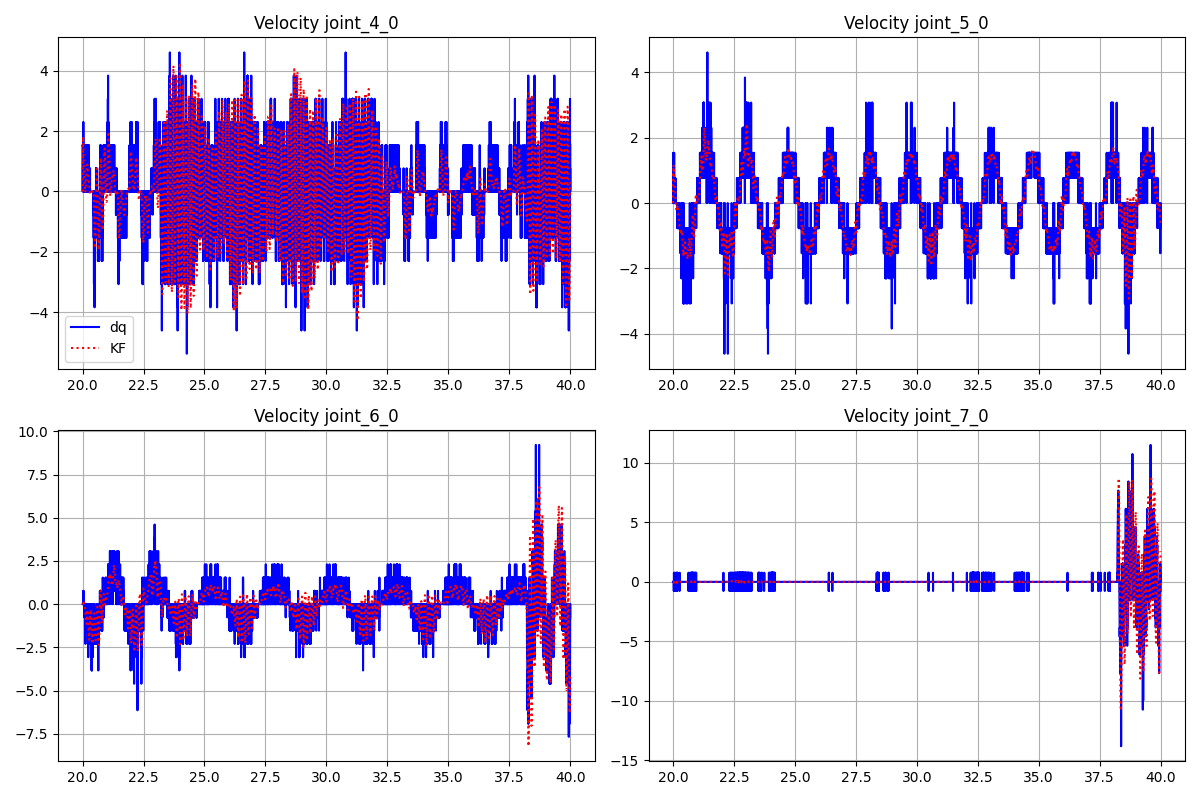

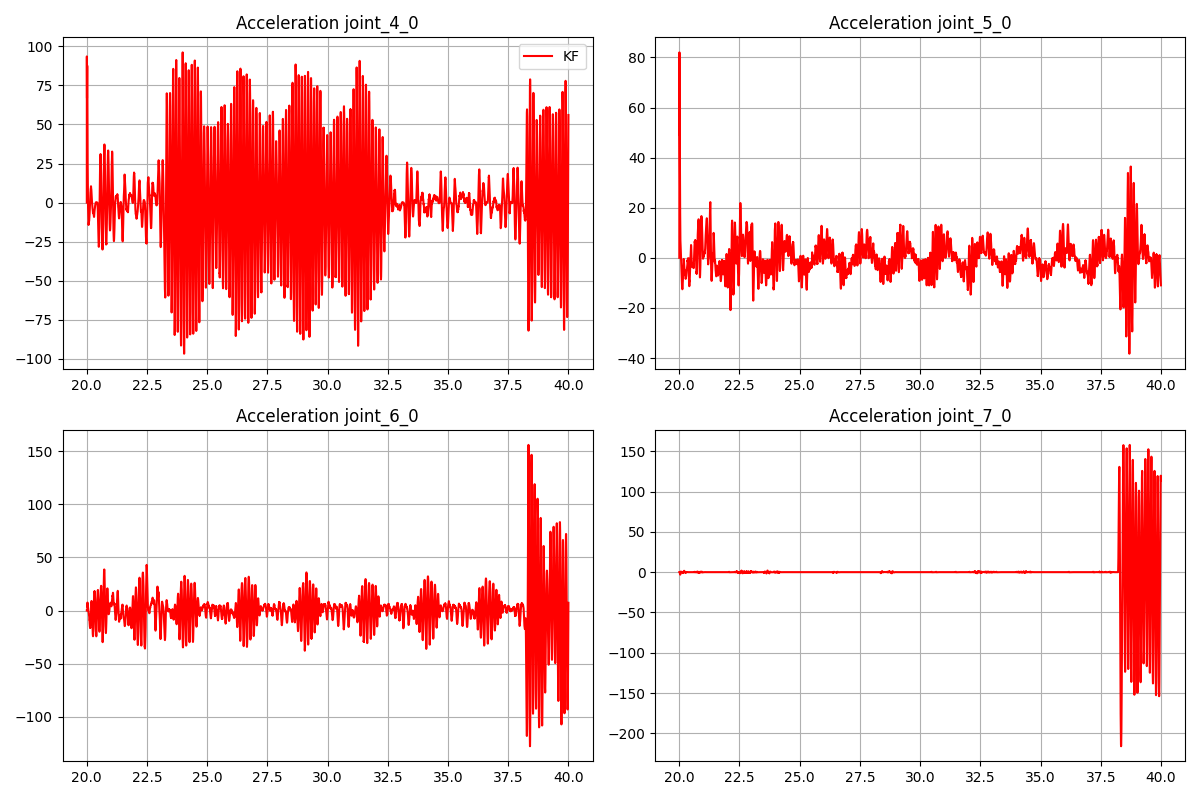

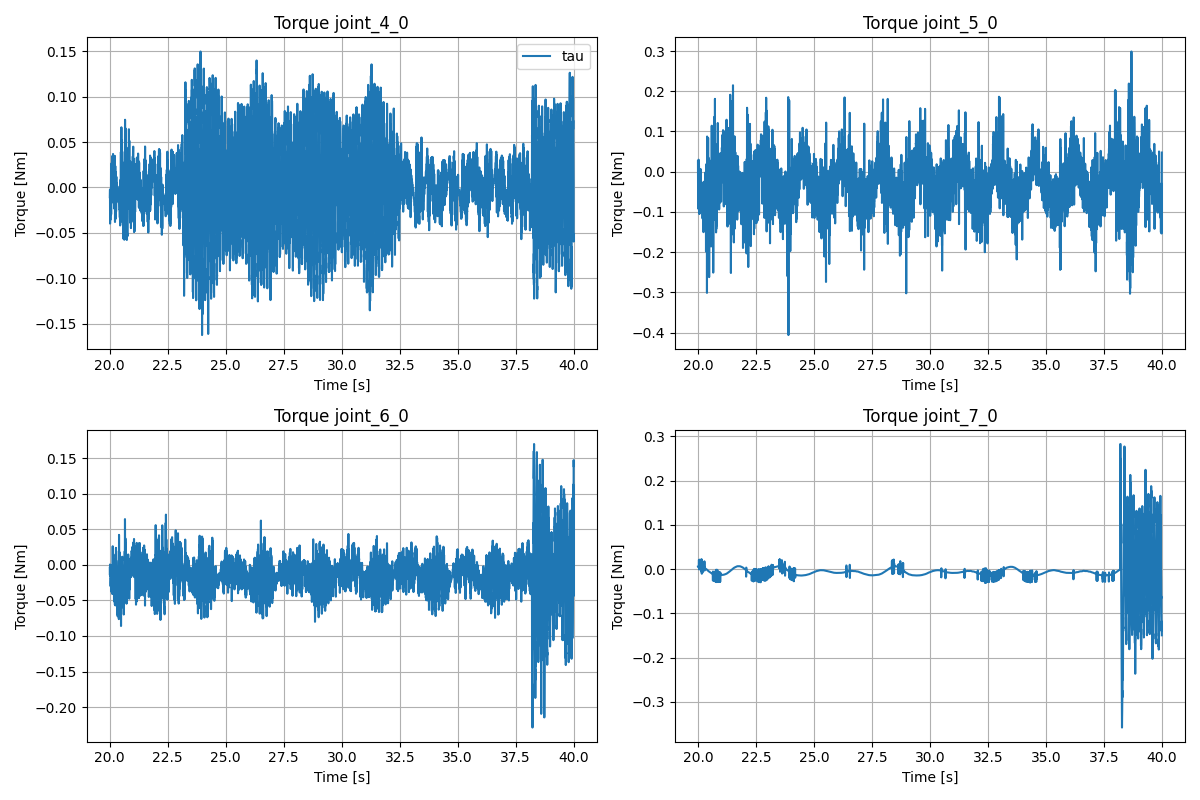

In [10]:
# =========================================================================================================================== Plot
# --- 1. Plot joint trajectories ---
plt.figure(figsize=(12,8))
for i in range(4):
    plt.subplot(2,2,i+1)
    plt.plot(t_log, q_ori[:,i], 'b', label='q')
    #plt.plot(t_log, q_log[:,i], 'r', label='q_filt')
    try:
        plt.plot(t_log2, q_log2[:,i], 'g', label='q_filt')
    except:
        pass
    plt.plot(t_log, q_kf_filt[:,i], 'r', linestyle='dotted', label='KF')
    #plt.plot(t_log, q_log[:,i] - e_log[:,i], 'b', linestyle='dotted', label='q_ref')# Plot joint desired trajectory
    #plt.hlines(JOINT_LIMITS[joint_indices[i], 0], t_log[0], t_log[-1], colors='k', linestyles='dotted', linewidth=1)
    #plt.hlines(JOINT_LIMITS[joint_indices[i], 1], t_log[0], t_log[-1], colors='k', linestyles='dotted', linewidth=1)
    plt.title(f'Position {JOINT_NAMES[i]}')
    plt.grid(True)
    if i==0:
        plt.legend()
plt.tight_layout()
plt.show()
# --- 1. Plot joint trajectories ---
plt.figure(figsize=(12,8))
for i in range(4):
    plt.subplot(2,2,i+1)
    plt.plot(t_log, qd_ori[:,i], 'b', label='dq')
    try:
        plt.plot(t_log2, qd_log2[:,i], 'g', label='q_filt')
    except:
        pass
    #plt.plot(t_log, qd_log[:,i], 'r', label='dq_filt')
    plt.plot(t_log, qd_kf_filt[:,i], 'r', linestyle='dotted', label='KF')
    plt.title(f'Velocity {JOINT_NAMES[i]}')
    plt.grid(True)
    if i==0:
        plt.legend()
plt.tight_layout()
plt.show()
plt.figure(figsize=(12,8))
for i in range(4):
    plt.subplot(2,2,i+1)
    #plt.plot(t_log, qdd[:,i], 'b', label='ddq')
    #plt.plot(t_log, qdd_log[:,i], 'r', label='ddq_filt')
    plt.plot(t_log, qdd_kf_filt[:,i], 'r', label='KF')
    plt.title(f'Acceleration {JOINT_NAMES[i]}')
    plt.grid(True)
    if i==0:
        plt.legend()
plt.tight_layout()
plt.show()

# --- 2. Plot joint tau ---
plt.figure(figsize=(12,8))
for i in range(4):
    plt.subplot(2,2,i+1)
    plt.plot(t_log, tau_ori[:,i], label = 'tau')
    plt.xlabel('Time [s]')
    plt.ylabel('Torque [Nm]')
    plt.title(f'Torque {JOINT_NAMES[i]}')
    plt.grid(True)
    if i==0:
        plt.legend()
plt.tight_layout()
plt.show(block=False)

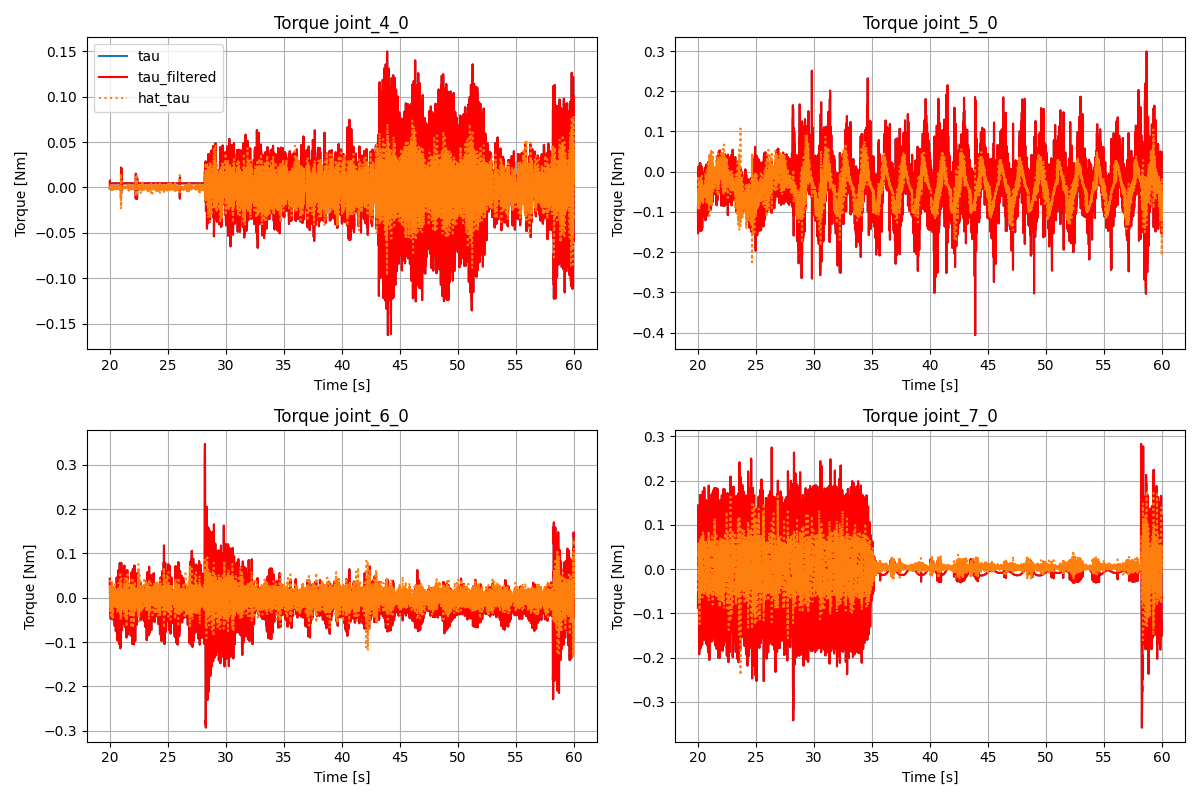

/tmp/ipykernel_54101/3315529719.py:19: RuntimeWarning: More than 20 figures have been opened. Figures created through the pyplot interface (`matplotlib.pyplot.figure`) are retained until explicitly closed and may consume too much memory. (To control this warning, see the rcParam `figure.max_open_warning`). Consider using `matplotlib.pyplot.close()`.
  plt.figure(figsize=(12,8))


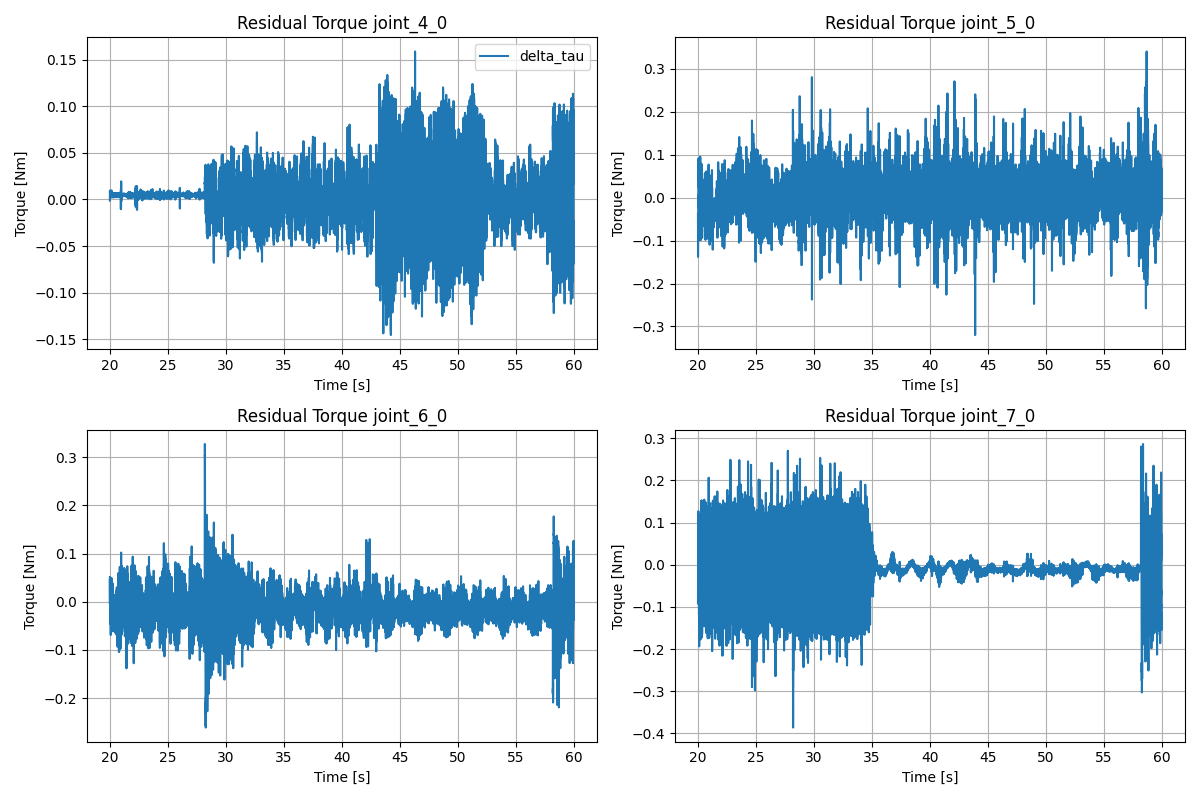

In [ ]:
# =========================================================================================================================== Plot
# --- 1. Plot joint trajectories ---
plt.figure(figsize=(12,8))
for i in range(4):
    plt.subplot(2,2,i+1)
    #plt.plot(t_log, tau_ori[:,i], label = 'tau')
    plt.plot(t_log, tau_log[:,i], 'r', label = 'tau_filtered')
    plt.plot(t_log, tau_log[:,i] - delta_tau[:,i], linestyle='dotted', label = 'hat_tau')
    plt.xlabel('Time [s]')
    plt.ylabel('Torque [Nm]')
    plt.title(f'Torque {JOINT_NAMES[i]}')
    plt.grid(True)
    if i==0:
        plt.legend()
plt.tight_layout()
plt.show(block=False)

# --- 3. Plot delta torques ---
plt.figure(figsize=(12,8))
for i in range(4):
    plt.subplot(2,2,i+1)
    plt.plot(t_log, delta_tau[:,i], label = 'delta_tau')
    plt.xlabel('Time [s]')
    plt.ylabel('Torque [Nm]')
    plt.title(f'Residual Torque {JOINT_NAMES[i]}')
    plt.grid(True)
    if i==0:
        plt.legend()
plt.tight_layout()
plt.show(block=False)

# --- 3. Plot delta torques ---
# plt.figure(figsize=(12,8))
# for i in range(4):
#     plt.subplot(2,2,i+1)
#     plt.plot(t_log, resid[i::4], label = 'delta_tau')
#     plt.xlabel('Time [s]')
#     plt.ylabel('Torque [Nm]')
#     plt.title(f'Joint {JOINT_NAMES[i]}')
#     plt.grid(True)
#     if i==0:
#         plt.legend()
# plt.tight_layout()
# plt.show()

# Verifie 2

In [25]:
INTERVAL = [12, 14]
SAVE = False

[INFO] [1762098505.775021192] [rosbag2_storage]: Opened database '/home/leo/Desktop/allegro_hand_ros2_ws/workdir/allegro_hand_test_traject_bag/allegro_hand_test_traject_bag_0.db3' for READ_ONLY.


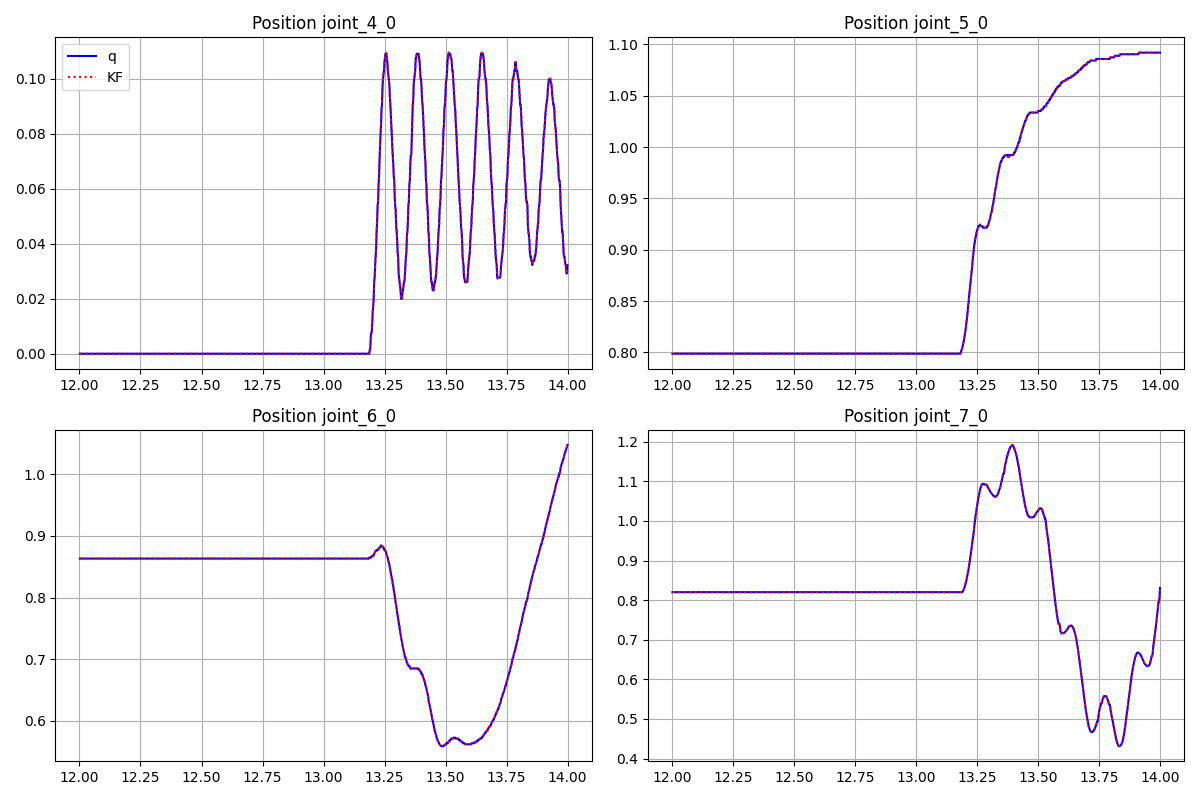

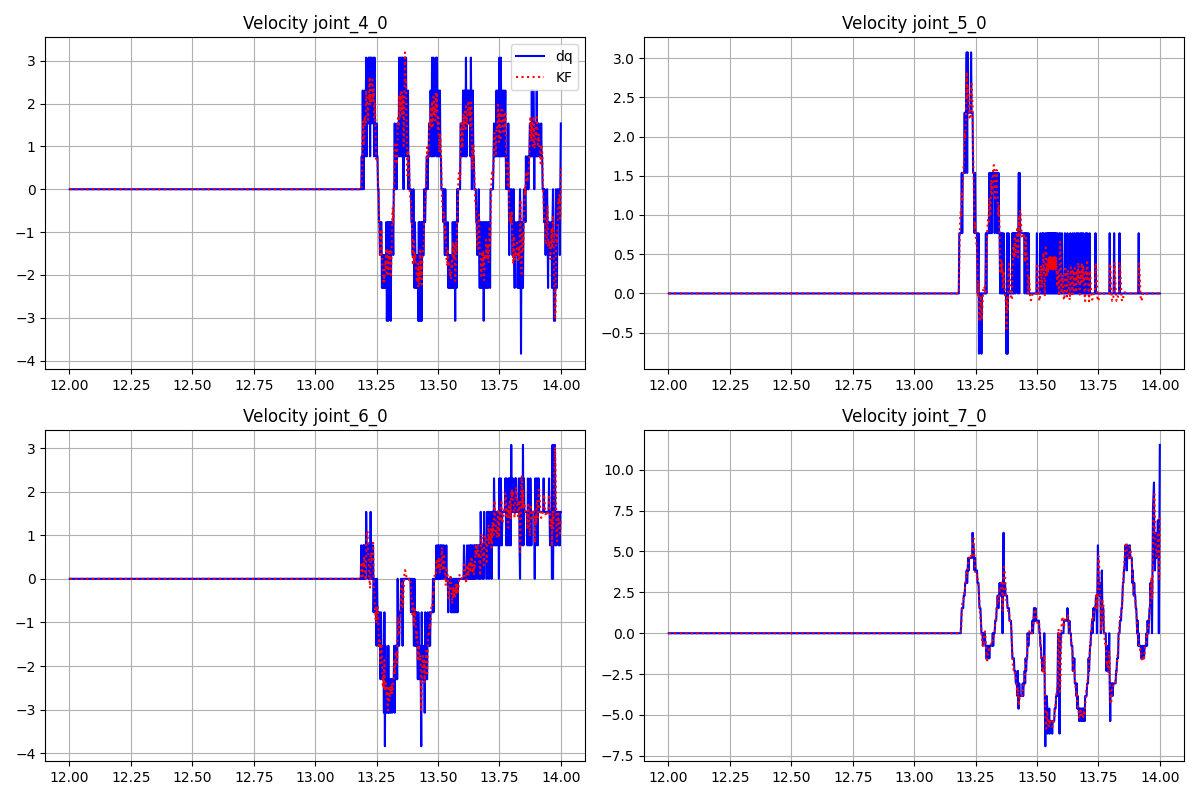

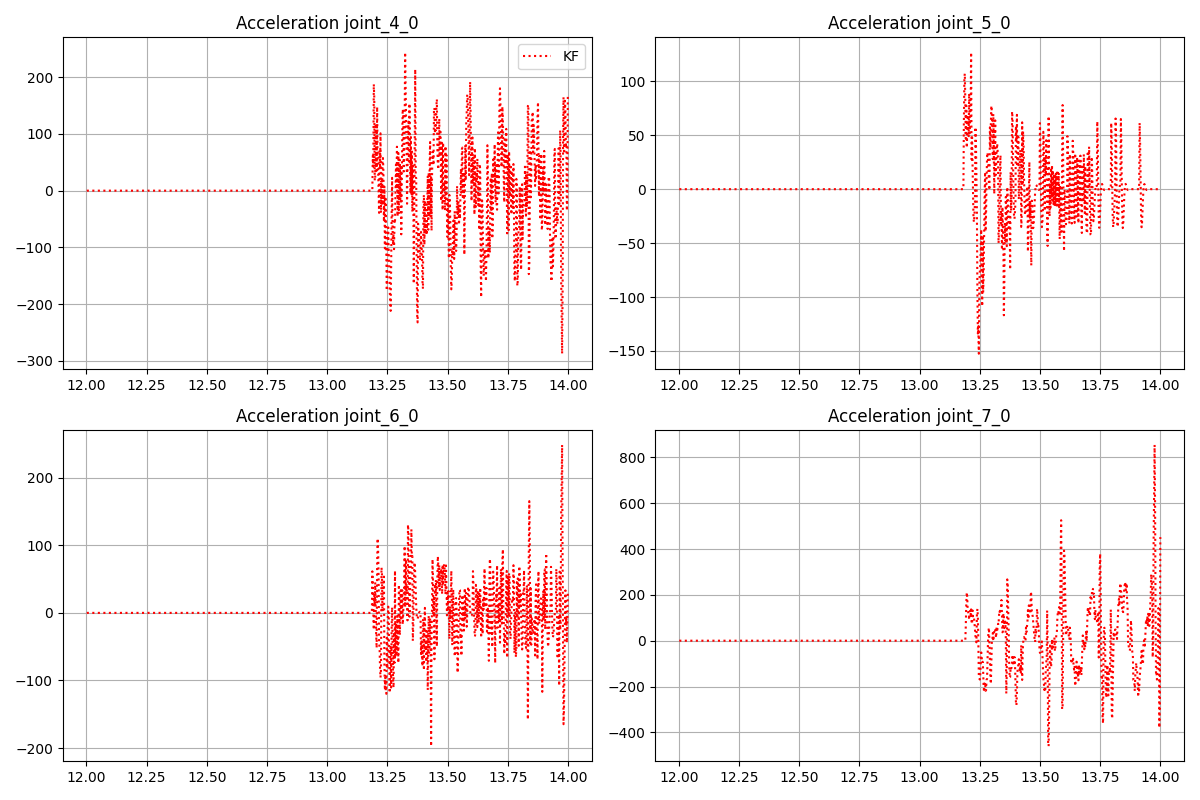

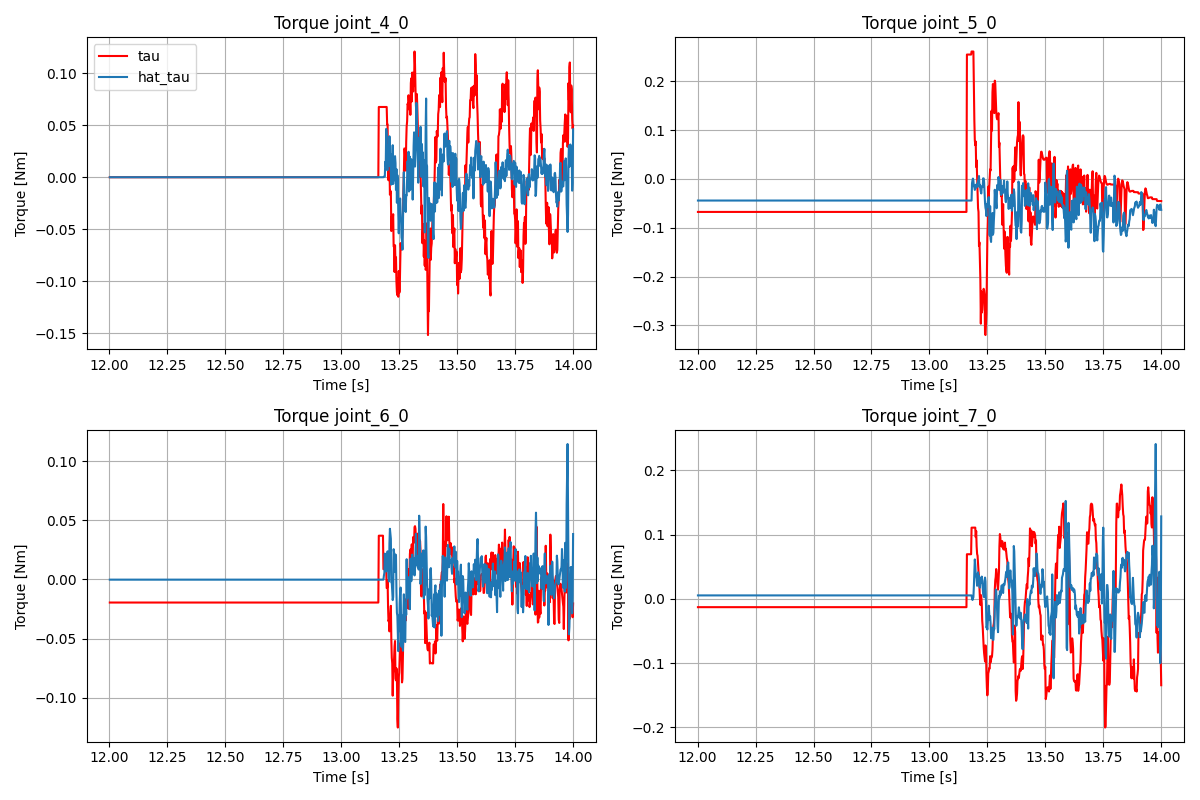

In [26]:
# =========================================================================================================================== Start
df = read_bag(BAG_PATH, topic_name='/allegroHand_0/joint_states', store=False)
#df2 = read_bag(BAG_PATH, topic_name='/allegroHand_0/torque_cmd',store=False)

t0 = df['t'].to_numpy()[0]


df = df[(df['t'] - t0 >= INTERVAL[0]) & (df['t'] - t0 <= INTERVAL[1])]
t_log = df['t'].to_numpy() - t0
q_log = df[[col for col in df.columns if col.startswith('pos_')]].to_numpy()
qd_log = df[[col for col in df.columns if col.startswith('vel_')]].to_numpy()
tau_log = df[[col for col in df.columns if col.startswith('eff_')]].to_numpy()

Dt = np.mean(np.diff(t_log))    # sampling period
F_s = 1.0 / Dt                  # sampling frequency
t_ori = t_log.copy()            # store original data
q_ori = q_log.copy()
qd_ori = qd_log.copy()
tau_ori = tau_log.copy()


"""
df2 = df2[(df2['t'] - t0 >= INTERVAL[0]) & (df2['t'] - t0 <= INTERVAL[1])]
t_log2 = df2['t'].to_numpy() - t0
q_log2 = df2[[col for col in df2.columns if col.startswith('pos_')]].to_numpy()
qd_log2 = df2[[col for col in df2.columns if col.startswith('vel_')]].to_numpy()
tau_log2 = df2[[col for col in df2.columns if col.startswith('eff_')]].to_numpy()
t_ori2 = t_log2.copy()            # store original data
q_ori2 = q_log2.copy()
qd_ori2 = qd_log2.copy()
tau_ori2 = tau_log2.copy()
"""

q_kf_filt = []
qd_kf_filt = []
qdd_kf_filt = []
q_tmp = []
qd_tmp = []
qdd_tmp = []

for i in range(len(t_log)):
#for i in range(5):
    for j in range(4):
        try:
            dt = t_log[i+1] - t_log[i]
        except:
            ft = t_log[i] - t_log[i-1]
        if i == 0:
            KFs[j].hat_x[0] = q_log[i][j]
        KFs[j].prediction(0.002)
        KFs[j].update(q_log[i][j])

        q_tmp.append(KFs[j].get_q())
        qd_tmp.append(KFs[j].get_qd())
        qdd_tmp.append(KFs[j].get_qdd())

    q_kf_filt.append(np.array(q_tmp))
    qd_kf_filt.append(np.array(qd_tmp))
    qdd_kf_filt.append(np.array(qdd_tmp))
    q_tmp = []
    qd_tmp = []
    qdd_tmp = []

q_kf_filt = np.array(q_kf_filt)
qd_kf_filt = np.array(qd_kf_filt)
qdd_kf_filt = np.array(qdd_kf_filt)

thunder_ahand.set_par_DYN(hat_Pi[:40])
delta_tau = []
for i in range(len(t_log)):
    #q =q_log[i,:]
    #dq = qd_log[i,:]
    #ddq = qdd_log[i,:]
    q = q_kf_filt[i,:]
    dq = qd_kf_filt[i,:]
    ddq = qdd_kf_filt[i,:]

    thunder_ahand.set_q(q)
    thunder_ahand.set_dq(dq)
    thunder_ahand.set_dqr(dq)
    thunder_ahand.set_ddqr(ddq)
    Y = thunder_ahand.get_reg_M() + thunder_ahand.get_reg_C() + thunder_ahand.get_reg_G()
    # add friction damping and static
    Y_d = np.diag(dq.flatten())
    Y_s = np.diag((2/(1+np.exp(-20*dq)) - 1).flatten())
    Y = np.hstack([Y, Y_d, Y_s])

    tau_est = np.array(Y @ hat_Pi).flatten()
    delta_tau.append(tau_log[i,:] - tau_est)
delta_tau = np.array(delta_tau)

# ===================================================================================================
# --- 2. Plot joint tau ---
plt.figure(figsize=(12,8))
for i in range(4):
    plt.subplot(2,2,i+1)
    plt.plot(t_log, q_ori[:,i], 'b', label='q')
    #plt.plot(t_log, q_log[:,i], 'r', label='q_filt')
    try:
        plt.plot(t_log2, q_log2[:,i], 'g', label='q_filt')
    except:
        pass
    plt.plot(t_log, q_kf_filt[:,i], 'r', linestyle='dotted', label='KF')
    #plt.plot(t_log, q_log[:,i] - e_log[:,i], 'b', linestyle='dotted', label='q_ref')# Plot joint desired trajectory
    #plt.hlines(JOINT_LIMITS[joint_indices[i], 0], t_log[0], t_log[-1], colors='k', linestyles='dotted', linewidth=1)
    #plt.hlines(JOINT_LIMITS[joint_indices[i], 1], t_log[0], t_log[-1], colors='k', linestyles='dotted', linewidth=1)
    plt.title(f'Position {JOINT_NAMES[i]}')
    plt.grid(True)
    if i==0:
        plt.legend()
plt.tight_layout()
plt.show()
if SAVE:
    plt.savefig(f"Joint_pos_{INTERVAL[0]}_{INTERVAL[1]}.png", dpi=300, bbox_inches='tight')
    print(f"Figure saved as Joint_pos_{INTERVAL[0]}_{INTERVAL[1]}.png")
# --- 1. Plot joint trajectories ---
plt.figure(figsize=(12,8))
for i in range(4):
    plt.subplot(2,2,i+1)
    plt.plot(t_log, qd_ori[:,i], 'b', label='dq')
    try:
        plt.plot(t_log2, qd_log2[:,i], 'g', label='q_filt')
    except:
        pass
    #plt.plot(t_log, qd_log[:,i], 'r', label='dq_filt')
    plt.plot(t_log, qd_kf_filt[:,i], 'r', linestyle='dotted', label='KF')
    plt.title(f'Velocity {JOINT_NAMES[i]}')
    plt.grid(True)
    if i==0:
        plt.legend()
plt.tight_layout()
plt.show()
if SAVE:
    plt.savefig(f"Joint_vel_{INTERVAL[0]}_{INTERVAL[1]}.png", dpi=300, bbox_inches='tight')
    print(f"Figure saved as Joint_vel_{INTERVAL[0]}_{INTERVAL[1]}.png")


plt.figure(figsize=(12,8))
for i in range(4):
    plt.subplot(2,2,i+1)
    plt.plot(t_log, qdd_kf_filt[:,i], 'r', linestyle='dotted', label='KF')
    plt.title(f'Acceleration {JOINT_NAMES[i]}')
    plt.grid(True)
    if i==0:
        plt.legend()
plt.tight_layout()
plt.show()
if SAVE:
    plt.savefig(f"Joint_acc_{INTERVAL[0]}_{INTERVAL[1]}.png", dpi=300, bbox_inches='tight')
    print(f"Figure saved as Joint_acc_{INTERVAL[0]}_{INTERVAL[1]}.png")

# --- 2. Plot joint tau ---
plt.figure(figsize=(12,8))
for i in range(4):
    plt.subplot(2,2,i+1)
    plt.plot(t_log, tau_log[:,i], 'r', label = 'tau')
    plt.plot(t_log, tau_log[:,i] - delta_tau[:,i], label = 'hat_tau')
    plt.xlabel('Time [s]')
    plt.ylabel('Torque [Nm]')
    plt.title(f'Torque {JOINT_NAMES[i]}')
    plt.grid(True)
    if i==0:
        plt.legend()
plt.tight_layout()
plt.show(block=False)
if SAVE:
    plt.savefig(f"Joint_torque_{INTERVAL[0]}_{INTERVAL[1]}.png", dpi=300, bbox_inches='tight')
    print(f"Figure saved as Joint_torque_{INTERVAL[0]}_{INTERVAL[1]}.png")
